# Overlap Calculation of S(E) curves

Assuming that the sample wasn't homogeneous and given our already made assumptions on the positron implantation and annihilation and diffusion mechanism, I here want to investigate what would happen, if we overlapped two S-parameter curves. One assuming a thing layer of oxide and one without any oxide. Since the positron partially probes a pure (steel, annealed) layer and an oxidized layer, I want to test this theory. 

But since the S-parameter is not linearly correlated with the depth (from density) in a multilayer system, we need the heatmap and a overlap method. 

In [1]:
import sys
sys.path.insert(0, r'C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Programming')

# Packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# Files importation
from pals_analysis import config
from pals_analysis.physics.implantation import makhov_profile
from pals_analysis.physics.annihilation import calculate_annihilation_profile
from pals_analysis.analysis.thickness_solver import numerical_S_curve
from pals_analysis.visualization.plots import create_heatmap
from pals_analysis.visualization import setup_plot_style

# Setting plotting style
plt.rcParams.update({
        'figure.figsize': (10, 6),
        'font.size': 11,
        'font.family': 'Times New Roman',
        'axes.labelsize': 12,
        'axes.titlesize': 14,
        'legend.fontsize': 10,
        'figure.dpi': 100,
        'savefig.dpi': 300,
        'grid.alpha': 0.3,
    })

colors = ["black", "grey", "red"] 
cmap_name = "steel_gradient"
n_bins = 100
norm = Normalize(vmin=0.0, vmax=1.0)
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

# Define energies we are probing
energies = np.linspace(0.1, 25, 100)  # in keV

def thickness_layer(layers):
    depth = 0
    i = 0
    for i in range(len(layers)):
        depth += layers[i]['thickness']
        i += 1
    
    return depth


In [2]:
# We define the layers we will be using.
# We also configure the grid and which one to use based its depth
# The function thickness_layer calculates the depth of each created layer.

layers_steel = [
    {'thickness': 1000, 'density': 8.00, 'L_diff': 150, 'S_param': 0.515}  # Steel (Substrate)
    ]

layers_oxsteel = [
    {'thickness': 4.0, 'density': 6.0, 'L_diff': 5, 'S_param': 0.570},

    # 2. OUTER OXIDE (Fe-Rich)
    # Porous, messy, high S. The "Top of the Hump".
    {'thickness': 80.0, 'density': 5.24, 'L_diff': 20, 'S_param': 0.590},

    # 3. INNER OXIDE (Cr-Rich)
    # Dense, compact. S drops slightly.
    {'thickness': 70.0, 'density': 5.22, 'L_diff': 40, 'S_param': 0.550},

    # 4. DEPLETION ZONE (New Layer!)
    # The steel region starved of Cr + Vacancy injection.
    # S is higher than bulk (due to vacancies) but lower than oxide.
    # L_diff is short (defects trap positrons).
    {'thickness': 10.0, 'density': 7.80, 'L_diff': 60, 'S_param': 0.535},

    # 5. BULK SUBSTRATE
    # The pristine, healed steel.
    {'thickness': 1000.0, 'density': 8.00, 'L_diff': 150, 'S_param': 0.515}
]

z_pts = 2000 # fineness of the grid

z_grid_steel = np.linspace(0, thickness_layer(layers_steel), z_pts)
z_grid_oxsteel = np.linspace(0, thickness_layer(layers_oxsteel), z_pts)

grids = [z_grid_steel, z_grid_oxsteel]

# Find the one with the largest maximum number (deepest)
z_master = max(grids, key=np.max)


Calculating S-curve based on layers and energies...
Saved: heatmap_sharp.pdf


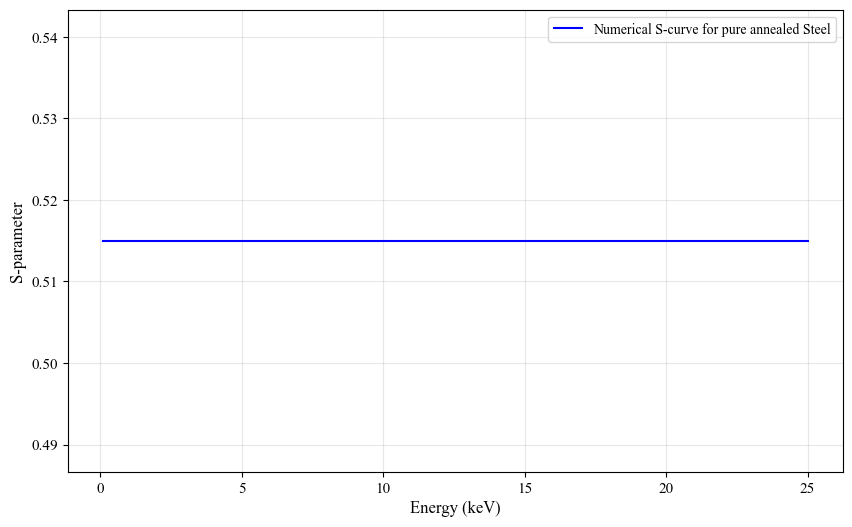

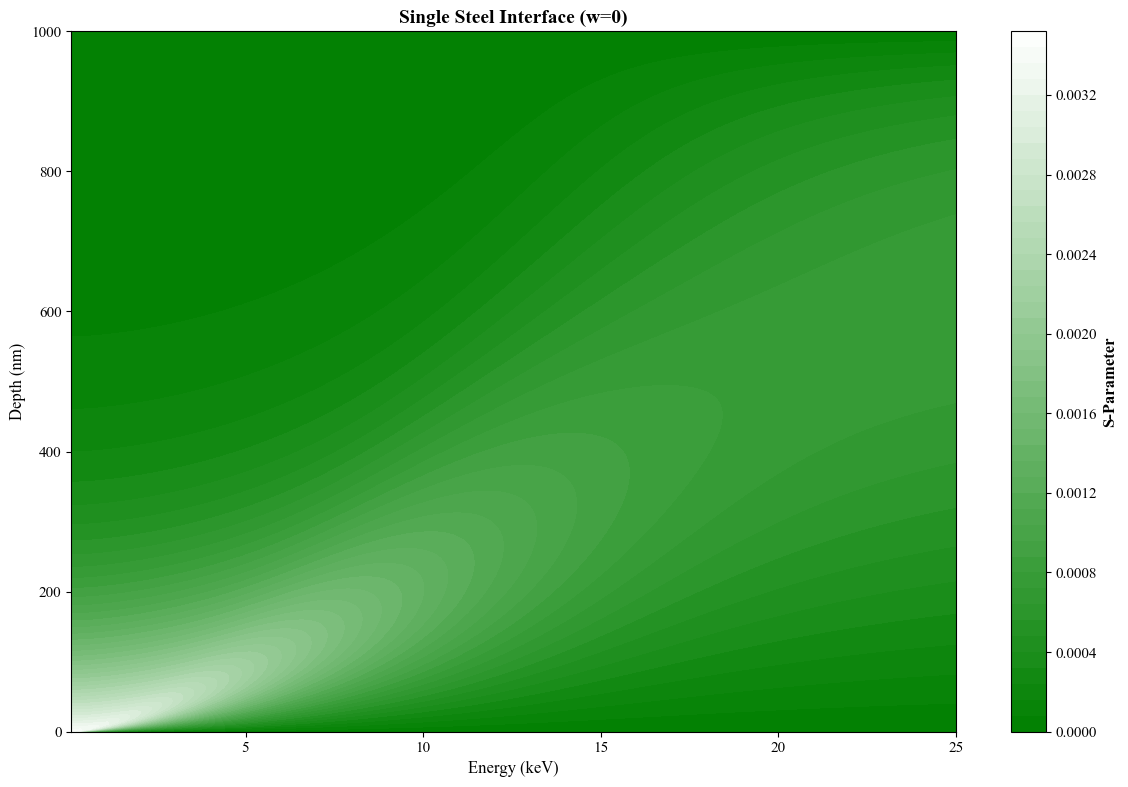

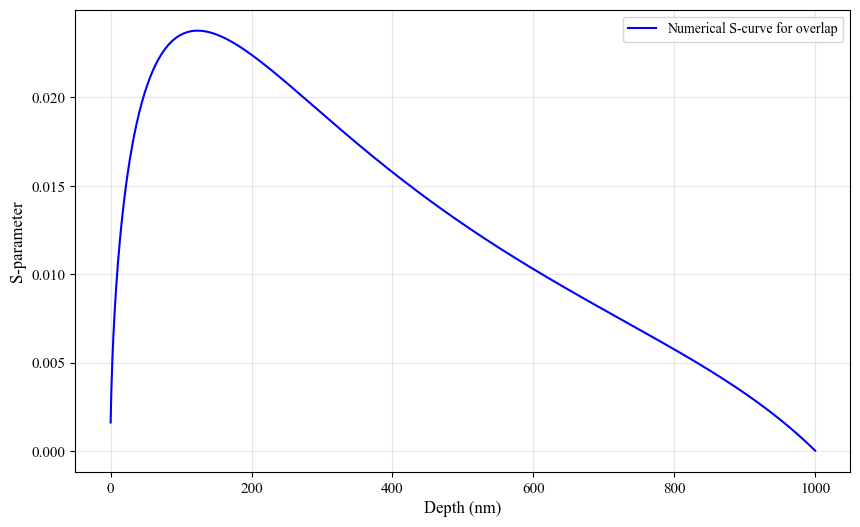

In [3]:
# Pure annealead Steel

# We define the layer
S_steel, S_map_steel = numerical_S_curve(layers_steel, energies, w=5, model='layered', 
                                         z_max=thickness_layer(layers_steel), 
                                         z_pts=z_pts
                                         )

# Generate 2D Heatmap of S-parameter vs energy (keV) and thickness (nm)
# We also convert to a depth profile to ensure consistency.
matrix_sharp_steel = []
for E in energies:
# Run Sharp (Standard)
    p_s = makhov_profile(z_grid_steel, E, layers_steel, model='layered')
    c_s = calculate_annihilation_profile(z_grid_steel, p_s, layers_steel, model='layered')
    matrix_sharp_steel.append(c_s * S_map_steel)

matrix_sharp_steel = np.array(matrix_sharp_steel)
S_fmap = np.trapezoid(matrix_sharp_steel, energies, axis=0)


setup_plot_style()
plt.plot(energies, S_steel, label="Numerical S-curve for pure annealed Steel", color='blue')
plt.xlabel("Energy (keV)")
plt.ylabel("S-parameter")
plt.legend()
plt.grid(True)

create_heatmap(
        energies, z_grid_steel, matrix_sharp_steel,
        title="Single Steel Interface (w=0)",
        save_as="heatmap_sharp.pdf",
    )

plt.figure()
plt.plot(z_grid_steel, S_fmap, label="Numerical S-curve for overlap", color='blue')
plt.xlabel("Depth (nm)")
plt.ylabel("S-parameter")
plt.legend()
plt.grid(True)


Calculating S-curve based on layers and energies...
Saved: heatmap_sharp.pdf


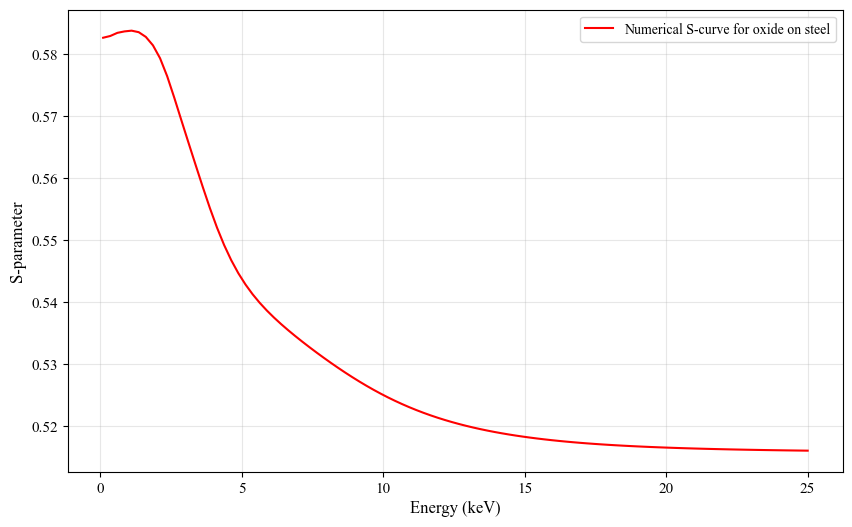

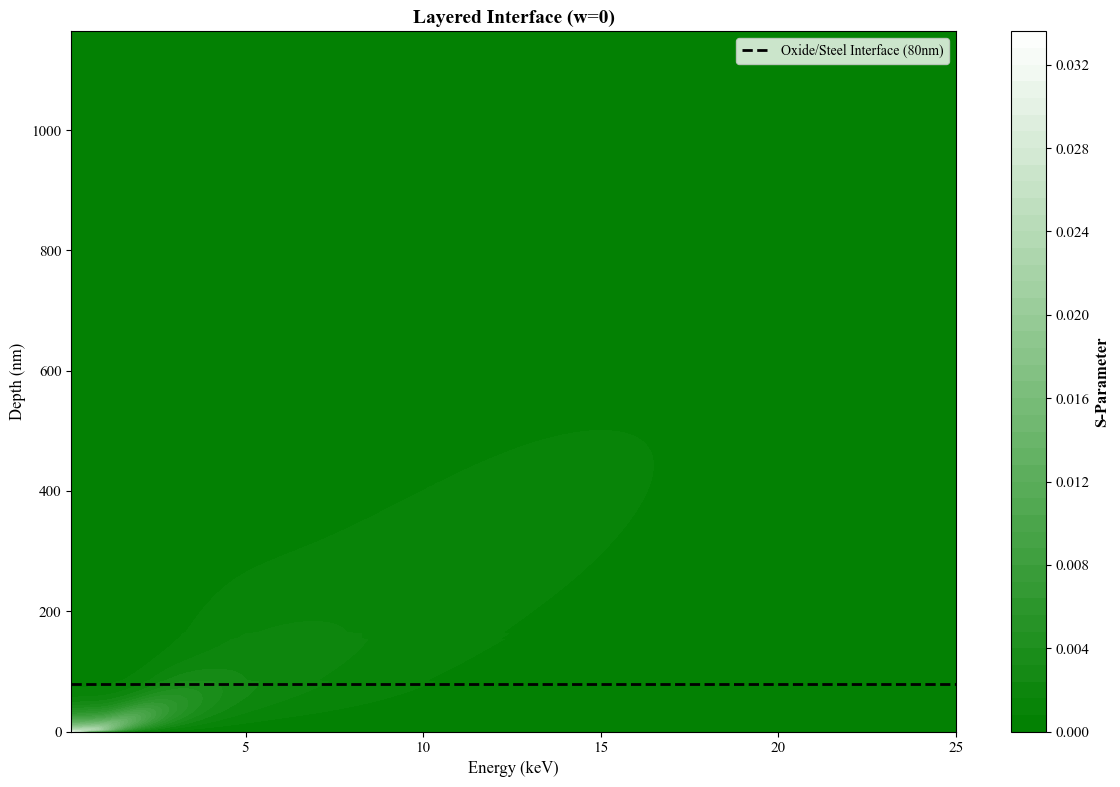

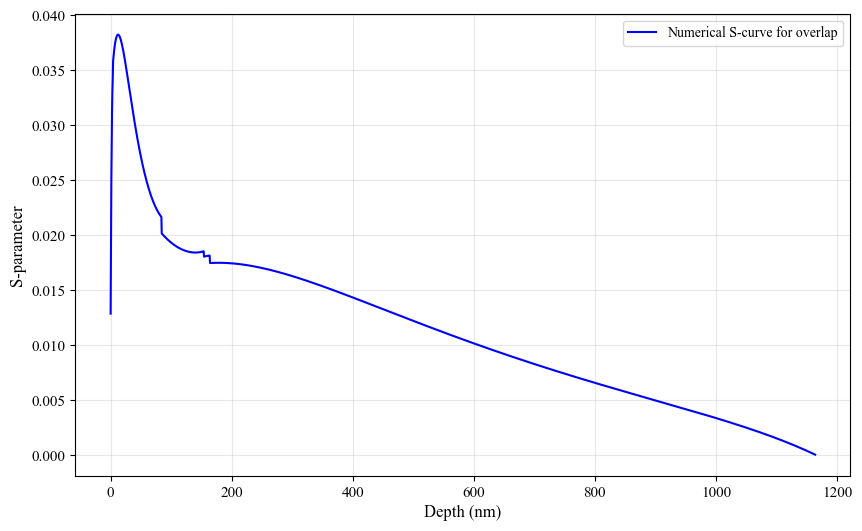

In [4]:
# Oxide on Steel

# We define the layer

# Generate numerical S-curve for layered model
S_oxide, S_map_oxide = numerical_S_curve(layers_oxsteel, energies, w=5, model='layered', 
                                         z_max=thickness_layer(layers_oxsteel), 
                                         z_pts=z_pts
                                         )

# Generate 2D Heatmap of S-parameter vs energy (keV) and thickness (nm)
matrix_sharp_oxide = []
    
for E in energies:
# Run Sharp (Standard)
    p_s = makhov_profile(z_grid_oxsteel, E, layers_oxsteel, model='layered')
    c_s = calculate_annihilation_profile(z_grid_oxsteel, p_s, layers_oxsteel, model='layered')
    matrix_sharp_oxide.append(c_s * S_map_oxide)

matrix_sharp_oxide = np.array(matrix_sharp_oxide)
S_fox = np.trapezoid(matrix_sharp_oxide, energies, axis=0)


setup_plot_style()
plt.plot(energies, S_oxide, label="Numerical S-curve for oxide on steel", color='red')
plt.xlabel("Energy (keV)")
plt.ylabel("S-parameter")
plt.legend()
plt.grid(True)


create_heatmap(
        energies, z_grid_oxsteel, matrix_sharp_oxide,
        title="Layered Interface (w=0)",
        save_as="heatmap_sharp.pdf",
        d_ox=layers_oxsteel[1]['thickness']
    )


plt.figure()
plt.plot(z_grid_oxsteel, S_fox, label="Numerical S-curve for overlap", color='blue')
plt.xlabel("Depth (nm)")
plt.ylabel("S-parameter")
plt.legend()
plt.grid(True)




Saved: heatmap_overlap_.pdf


(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Overlap Heatmap (40.0% Oxide Coverage)'}, xlabel='Energy (keV)', ylabel='Depth (nm)'>)

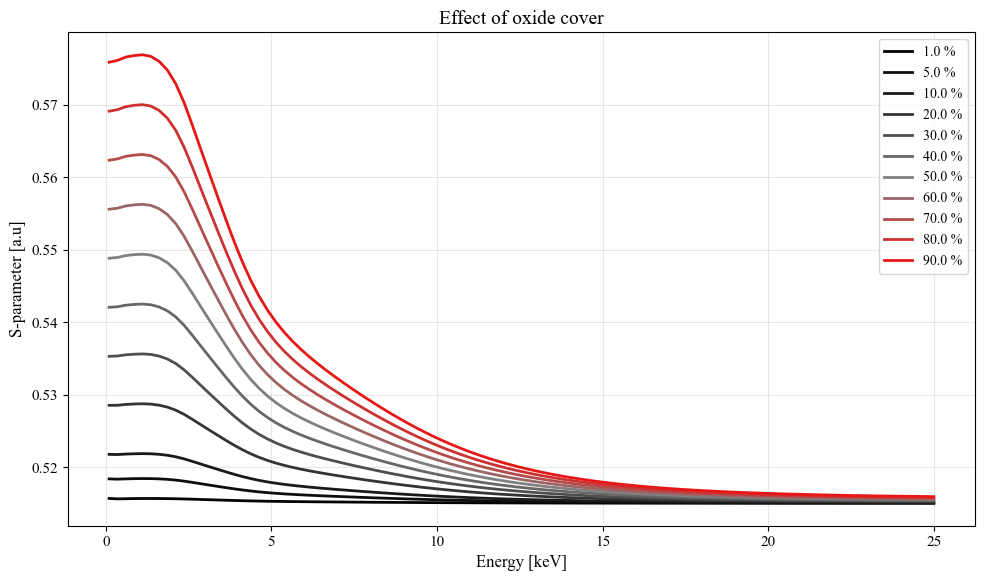

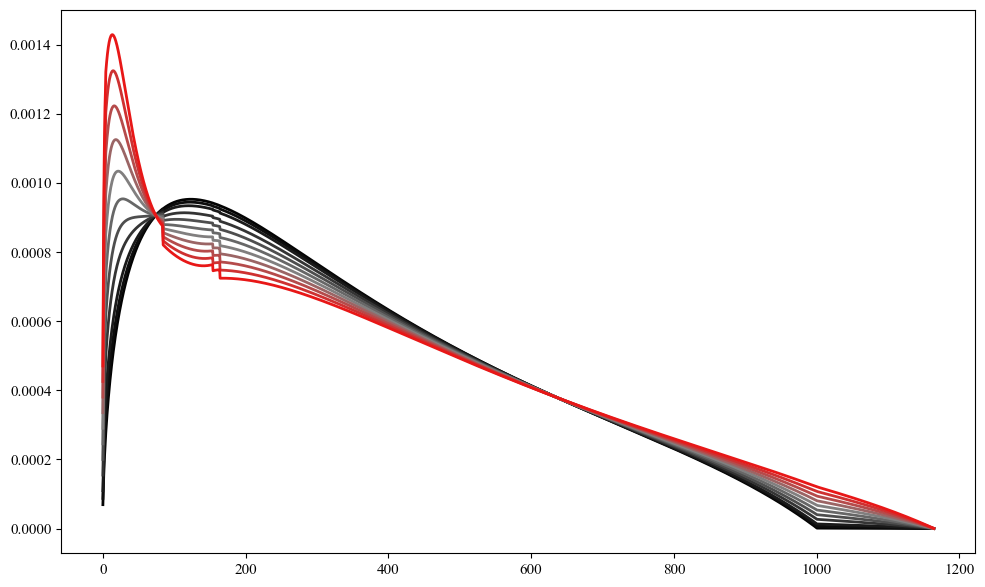

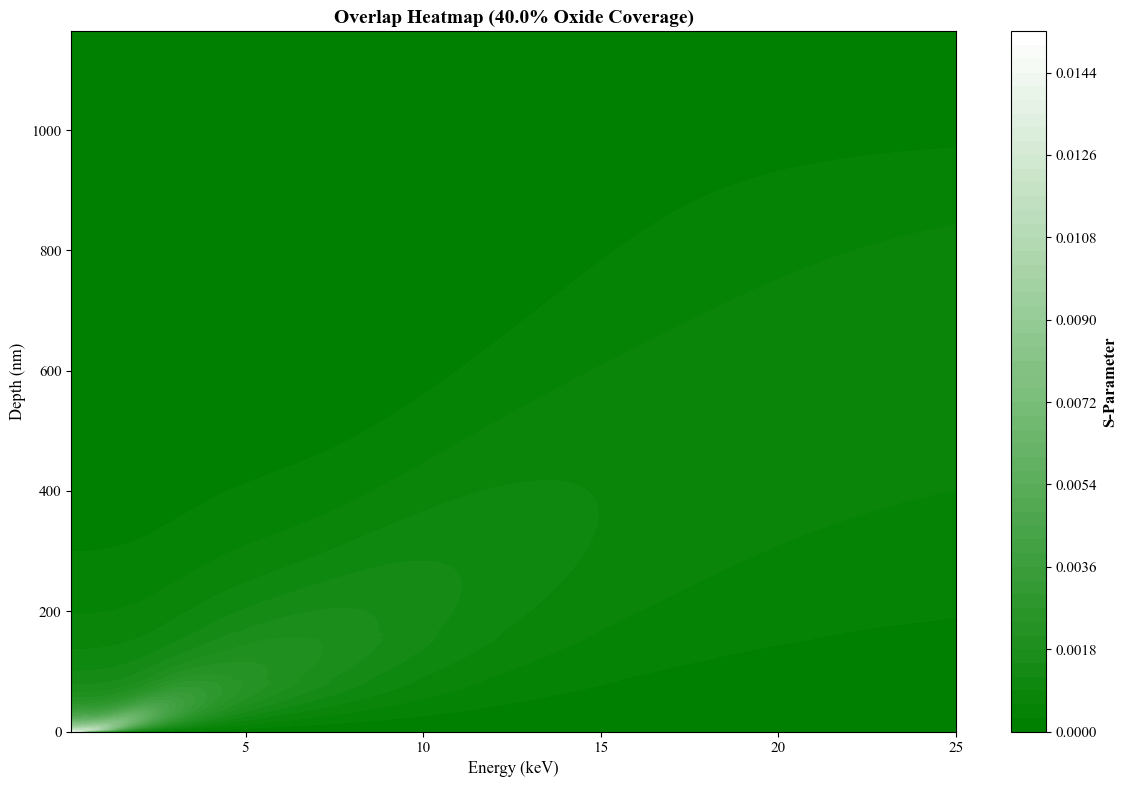

In [5]:
# Overlap of heatmaps
# Having generated both heatmaps, we can now overlap them
# to see the effect of the oxide layer on the S-parameter profile.

# Shift the steel heatmap to align with the oxide on steel heatmap
# This is done by adding zeros for the oxide layer thickness

matrix_steel_interp = np.zeros_like(matrix_sharp_oxide)

for i, energy in enumerate(energies):
    # Get the row from the original Steel calculation
    steel_signal_row = matrix_sharp_steel[i, :]
    
    # INTERPOLATE:
    # "For every point in z_master, find the value based on (z_grid_steel, steel_signal_row)"
    # left=0, right=0 ensures we don't extrapolate into vacuum or deep bulk incorrectly
    interpolated_row = np.interp(z_master, z_grid_steel, steel_signal_row, left=0, right=0)
    
    matrix_steel_interp[i, :] = interpolated_row



setup_plot_style()
# Surface coverage values iteration. Oxide coverage
surface_coverage = [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
fig, ax = plt.subplots(figsize=(10, 6))
    
for i, c in enumerate(surface_coverage):
        matrix_overlap = (c * matrix_sharp_oxide) + ((1 - c) * matrix_steel_interp)
        S_overlap = np.trapezoid(matrix_overlap, z_master, axis=1)
        current_color = custom_cmap(norm(c))
        ax.plot(energies, S_overlap, 
                label=f'{c*100} %', linewidth=2, color=current_color)
    
#ax.axvline(155, color='black', linestyle='--', alpha=0.5, label='Interface')
ax.set_xlabel('Energy [keV]', fontsize=14)
#ax.set_xlabel('Depth [nm]', fontsize=12, fontweight='bold')
ax.set_ylabel('S-parameter [a.u]', fontsize=14)
ax.set_title(f'Effect of oxide cover', 
                 fontsize=20, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# 
fig, ax1 = plt.subplots(figsize=(10, 6))



for i, c in enumerate(surface_coverage):
        matrix_overlap = (c * matrix_sharp_oxide) + ((1 - c) * matrix_steel_interp)
        S_overlap = np.trapezoid(matrix_overlap, energies, axis=0) /(energies[-1] - energies[0])
        current_color = custom_cmap(norm(c))
        ax1.plot(z_master, S_overlap, 
                label=f'{c*100} %', linewidth=2, color=current_color)
    
#ax.axvline(155, color='black', linestyle='--', alpha=0.5, label='Interface')
ax.set_xlabel('Energy [keV]', fontsize=12)
#ax.set_xlabel('Depth [nm]', fontsize=12, fontweight='bold')
ax.set_ylabel('S-parameter [a.u]', fontsize=12)
ax.set_title(f'Effect of oxide cover', 
                 fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


c = 0.40
matrix_overlap = (c * matrix_sharp_oxide) + ((1 - c) * matrix_steel_interp)
create_heatmap(energies, z_master, matrix_overlap,
        title=f"Overlap Heatmap ({c*100}% Oxide Coverage)",
        save_as="heatmap_overlap_.pdf",
)